# Substituição prova

Começarei pela questão 1:

In [2]:
W = 25
W1,W2,W3,W4,W5,W6,W7,W8,W9,W10 = 5,7,3,6,4,2,2,9,8,5
V1,V2,V3,V4,V5,V6,V7,V8,V9,V10 = 70,80,50,90,60,40,30,85,75,55

from pulp import *

FP = LpProblem("FP", LpMaximize)

lp = LpProblem("bond-problem",LpMaximize) #problema 3.b

S1 = LpVariable(name="S1", lowBound=0, upBound=1, cat="Integer")
S2 = LpVariable(name="S2", lowBound=0, upBound=1, cat="Integer")
S3 = LpVariable(name="S3", lowBound=0, upBound=1, cat="Integer")
S4 = LpVariable(name="S4", lowBound=0, upBound=1, cat="Integer")
S5 = LpVariable(name="S5", lowBound=0, upBound=1, cat="Integer")
S6 = LpVariable(name="S6", lowBound=0, upBound=1, cat="Integer")
S7 = LpVariable(name="S7", lowBound=0, upBound=1, cat="Integer")
S8 = LpVariable(name="S8", lowBound=0, upBound=1, cat="Integer")
S9 = LpVariable(name="S9", lowBound=0, upBound=1, cat="Integer")
S10 = LpVariable(name="S10", lowBound=0, upBound=1, cat="Integer")

lp += V1*S1 + V2*S2 + V3*S3 + V4*S4 + V5*S5 + V6*S6 + V7*S7 + V8*S8 + V9*S9 + V10*S10

#as restrições tinham modelos diferentes
lp += W1*S1 + W2*S2 + W3*S3 + W4*S4 + W5*S5 + W6*S6 + W7*S7 + W8*S8 + W9*S9 + W10*S10 <= W # capacidade da mochila
lp += S1 + S2 + S3 + S4 <= 1  # 1."Apenas um, dentre os itens {1, 2, 3, 4} podem ser escolhidos."
lp += S1 + S9 <= 1 # 2. "Caso o item 1 seja escolhido, o item 9 não pode ser escolhido."
lp += S6 + S7 + S8 >= 1 # 3. "Pelo menos um entre os itens {6, 7, 8} tem que ser escolhido."

status = lp.solve()

to_put = []
to_not_put = []

for var in lp.variables():
    if var.value() == 1:
        to_put.append(var.name)
        continue
    if var.value() == 0:
        to_not_put.append(var.name)

print("Os itens a serem postos são:", to_put)
print("Os itens a não serem postos são:", to_not_put)
print("O valor máximo a por é", lp.objective.value())

Os itens a serem postos são: ['S10', 'S4', 'S5', 'S6', 'S9']
Os itens a não serem postos são: ['S1', 'S2', 'S3', 'S7', 'S8']
O valor máximo a por é 320.0


Seguem algumas ilustrações da questão 2.a. Onde primeiro eu mostrei a região factível e outra somente com as limitações justas. (feitas no geogebra)

![alt text](fig2.png)

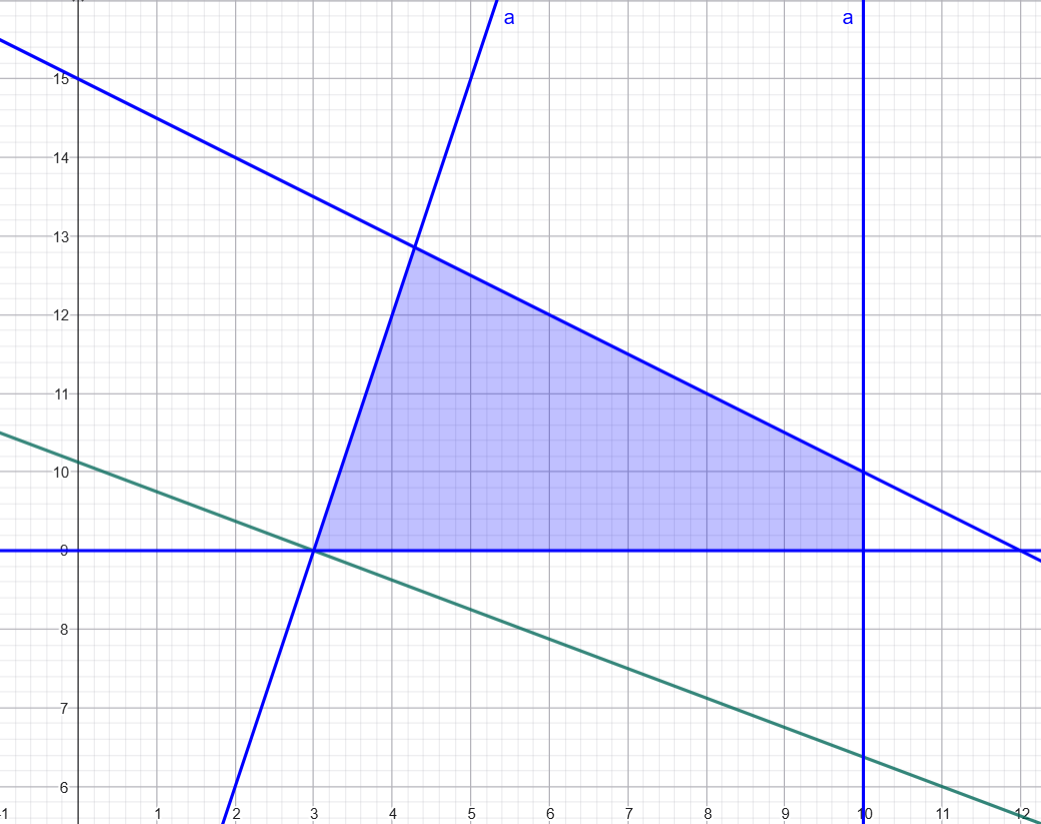

O algoritmo simplex começaria no vértice que usasse somente as variáveis adicionais e percorreria os vértices até não conseguir chegar aumentar a função objetivo. (obs: link do vídeo comentado [text](https://www.youtube.com/watch?v=E72DWgKP_1Y))

Agora farei o código da questão 3, fortemente inspirado no seguinte código do meu colega thiago pois fiz uma revisão em cima dele:

In [3]:
# Tabuleiro inicial de exemplo (0 = célula vazia)
initial_board = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9]
]

print("Tabuleiro inicial:")
for row in initial_board:
    print(' '.join(str(x) if x != 0 else '.' for x in row))

# Criar problema de factibilidade
prob = pulp.LpProblem("Sudoku", LpMinimize)

# Variáveis de decisão
x = pulp.LpVariable.dicts("x",
                         [(i, j, k) for i in range(9) for j in range(9) for k in range(1, 10)],
                         cat='Binary')

# Função objetivo dummy
prob += 0

# Restrição: cada célula tem exatamente um valor
for i in range(9):
    for j in range(9):
        prob += pulp.lpSum(x[(i, j, k)] for k in range(1, 10)) == 1

# Restrição: cada número aparece exatamente uma vez por linha
for i in range(9):
    for k in range(1, 10):
        prob += pulp.lpSum(x[(i, j, k)] for j in range(9)) == 1

# Restrição: cada número aparece exatamente uma vez por coluna
for j in range(9):
    for k in range(1, 10):
        prob += pulp.lpSum(x[(i, j, k)] for i in range(9)) == 1

# Restrição: cada número aparece exatamente uma vez por submatriz 3x3
for block_row in range(3):
    for block_col in range(3):
        for k in range(1, 10):
            prob += pulp.lpSum(x[(i, j, k)]
                             for i in range(block_row*3, block_row*3+3)
                             for j in range(block_col*3, block_col*3+3)) == 1

# Valores pré-atribuídos
for i in range(9):
    for j in range(9):
        if initial_board[i][j] != 0:
            k = initial_board[i][j]
            prob += x[(i, j, k)] == 1

# Resolver
prob.solve()

if LpStatus[prob.status] == 'Optimal':
    print("\nSolução encontrada!")

    # Construir tabuleiro solução
    solution = [[0 for _ in range(9)] for _ in range(9)]
    for i in range(9):
        for j in range(9):
            for k in range(1, 10):
                if x[(i, j, k)].varValue > 0.5:
                    solution[i][j] = k

    # Imprimir solução
    print("\nSolução:")
    for i in range(9):
        row = []
        for j in range(9):
            row.append(str(solution[i][j]))
        print(' '.join(row))
else:
    print("\nNenhuma solução encontrada!")

Tabuleiro inicial:
5 3 . . 7 . . . .
6 . . 1 9 5 . . .
. 9 8 . . . . 6 .
8 . . . 6 . . . 3
4 . . 8 . 3 . . 1
7 . . . 2 . . . 6
. 6 . . . . 2 8 .
. . . 4 1 9 . . 5
. . . . 8 . . 7 9

Solução encontrada!

Solução:
5 3 4 6 7 8 9 1 2
6 7 2 1 9 5 3 4 8
1 9 8 3 4 2 5 6 7
8 5 9 7 6 1 4 2 3
4 2 6 8 5 3 7 9 1
7 1 3 9 2 4 8 5 6
9 6 1 5 3 7 2 8 4
2 8 7 4 1 9 6 3 5
3 4 5 2 8 6 1 7 9


Em seguida mostrarei a minha adaptação para o problema pedido.

In [ ]:
# Dados de entrada - exemplo com pistas
initial_board = [
    [1, 0, 0, 4, 0, 0],  # A _ _ D _ _
    [0, 2, 0, 0, 5, 0],  # _ B _ _ E _
    [0, 0, 3, 0, 0, 6],  # _ _ C _ _ F
    [4, 0, 0, 1, 0, 0],  # D _ _ A _ _
    [0, 5, 0, 0, 2, 0],  # _ E _ _ B _
    [0, 0, 6, 0, 0, 3]   # _ _ F _ _ C
]

prob = LpProblem("Sudoku_6x6", LpMinimize)

# Variáveis de decisão - matriz 6x6x6
x = pulp.LpVariable.dicts("x", (range(6), range(6), range(1, 7)), 
                         lowBound=0, upBound=1, cat="Integer")

# Função objetivo dummy
prob += 0

# Restrição: cada célula tem exatamente um valor
for i in range(6):
    for j in range(6):
        prob += pulp.lpSum(x[i][j][k] for k in range(1, 7)) == 1

# Restrição: cada letra aparece exatamente uma vez por linha
for i in range(6):
    for k in range(1, 7):
        prob += pulp.lpSum(x[i][j][k] for j in range(6)) == 1

# Restrição: cada letra aparece exatamente uma vez por coluna  
for j in range(6):
    for k in range(1, 7):
        prob += pulp.lpSum(x[i][j][k] for i in range(6)) == 1

# Restrição CORRIGIDA: cada letra aparece exatamente uma vez por bloco 2x3
# Blocos: 3 blocos horizontais × 2 blocos verticais = 6 blocos no total
for block_row in range(2):    # 2 linhas de blocos
    for block_col in range(3): # 3 colunas de blocos
        for k in range(1, 7):
            prob += pulp.lpSum(x[i][j][k] 
                             for i in range(block_row*3, block_row*3+3)
                             for j in range(block_col*2, block_col*2+2)) == 1

# Valores pré-atribuídos (pistas iniciais)
for i in range(6):
    for j in range(6):
        if initial_board[i][j] != 0:
            k = initial_board[i][j]
            prob += x[i][j][k] == 1

# Resolver
prob.solve()

# Processar e exibir resultados
if LpStatus[prob.status] == 'Optimal':
    print("Solução encontrada!")
    
    # Mapeamento numérico para letras
    letras = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F'}
    
    # Construir solução
    solution = [['' for _ in range(6)] for _ in range(6)]
    for i in range(6):
        for j in range(6):
            for k in range(1, 7):
                if pulp.value(x[i][j][k]) > 0.5:
                    solution[i][j] = letras[k]
    
    # Imprimir solução completa
    print("\nSolução Completa (6×6):")
    print("=" * 20)
    for i in range(6):
        print(' '.join(solution[i]))
            
else:
    print("Nenhuma solução encontrada! Status:", LpStatus[prob.status])

Solução encontrada!

Solução Completa (6×6):
A F E D C B
C B A F E D
E D C B A F
D C B A F E
F E D C B A
B A F E D C


Agora de fato a questão 4:

In [ ]:
# Matrizes A (tecido saudável) e B (tecido doente)
A = np.array([
    [0.4, -0.7],
    [-1.5, -1.0],
    [-1.4, -0.9],
    [-1.3, -1.2],
    [-1.1, -0.2],
    [-1.2, -0.4],
    [-0.5, 1.2],
    [-1.5, 2.1],
    [1.0, 1.0]
])

B = np.array([
    [1.3, 0.8],
    [1.2, 0.5],
    [0.2, -2.0],
    [0.5, -2.4],
    [0.2, -2.3],
    [0.0, 2.7],
    [1.3, 2.1]
])

m, n = A.shape  # m observações, n parâmetros
p, _ = B.shape   # p observações

prob = pulp.LpProblem("Separacao", pulp.LpMinimize)

# Vetor 'a' (componentes podem ser positivos ou negativos)
a = pulp.LpVariable.dicts("a", range(n), cat='Continuous')

# Escalar 'b' (intercepto do hiperplano central)
b = pulp.LpVariable("b", cat='Continuous')

# Variáveis auxiliares 'u' para linearizar a norma L1 de 'a' (u_i = |a_i|)
u = pulp.LpVariable.dicts("u", range(n), lowBound=0)

# Função objetivo: Minimizar a norma L1 do vetor 'a'
prob += pulp.lpSum(u)

# Definindo a norma L1 de 'a' usando as variáveis auxiliares 'u'
for i in range(n):
    prob += u[i] >= a[i]
    prob += u[i] >= -a[i]

# Restrições para os dados da matriz A (tecido saudável)
# a^T * x - b <= -1
for i in range(m):
    prob += pulp.lpSum([a[j] * A[i][j] for j in range(n)]) - b <= -1

# Restrições para os dados da matriz B (tecido doente)
# a^T * x - b >= 1
for i in range(p):
    prob += pulp.lpSum([a[j] * B[i][j] for j in range(n)]) - b >= 1

prob.solve()

#a parte da exibição dos resultados foi grande parte feita por IA
print(f"Status da Solução: {pulp.LpStatus[prob.status]}")

if pulp.LpStatus[prob.status] == 'Optimal':
    # Extrair os valores ótimos
    a_sol = np.array([var.varValue for var in a])
    b_sol = b.varValue
    
    # Calcular b1 e b2 da formulação original
    b1_sol = b_sol - 1
    b2_sol = b_sol + 1
    
    print("\n--- Resultados Ótimos ---")
    print(f"Vetor 'a': {a_sol}")
    print(f"Escalar b1: {b1_sol:.4f}")
    print(f"Escalar b2: {b2_sol:.4f}")
    
    # A margem (distância) maximizada é 2 / ||a||_1
    norma_l1_a = sum(abs(val) for val in a_sol)
    distancia = (b2_sol - b1_sol) / norma_l1_a
    
    print(f"\nOs hiperplanos de separação são:")
    print(f"Para o tecido saudável (A): {a_sol[0]:.4f}*x1 + {a_sol[1]:.4f}*x2 <= {b1_sol:.4f}")
    print(f"Para o tecido doente (B):   {a_sol[0]:.4f}*x1 + {a_sol[1]:.4f}*x2 >= {b2_sol:.4f}")
    print(f"\nDistância maximizada entre oiz A (tecido saudável)s hiperplanos (usando norma L1): {distancia:.4f}")
else:
    print("\nNão foi possível encontrar uma solução ótima.")

Status da Solução: Infeasible

Não foi possível encontrar uma solução ótima.


Sabendo do problema, propus uma solução alternativa usando uma restrição que pune os pontos errados.

In [13]:

prob = pulp.LpProblem("Separacao_Hiperplano_Margem_Suave", pulp.LpMinimize)

# Parâmetro de regularização C. Controla a penalidade por erros.
C = 10 # Um valor comum para começar

# Vetor 'a' (componentes podem ser positivos ou negativos)
a = pulp.LpVariable.dicts("a", range(n), cat='Continuous')

# Escalar 'b' (intercepto do hiperplano central)
b = pulp.LpVariable("b", cat='Continuous')

# Variáveis auxiliares 'u' para linearizar a norma L1 de 'a' (u_i = |a_i|)
u = pulp.LpVariable.dicts("u", range(n), lowBound=0)

# Variáveis de folga (slack variables) para a margem
# alfa para os pontos em A e beta para os pontos em B
alfa = pulp.LpVariable.dicts("alfa", range(m), lowBound=0)
beta = pulp.LpVariable.dicts("beta", range(p), lowBound=0)

# Minimizar a norma de 'a' E a soma ponderada dos erros (folgas)
norma_l1_a = pulp.lpSum(u)
soma_erros = C * (pulp.lpSum(alfa) + pulp.lpSum(beta))
prob += norma_l1_a + soma_erros, "Objetivo_Margem_Suave"

for i in range(n):
    prob += u[i] >= a[i] 
    prob += u[i] >= -a[i]

# Restricao considerando o erro: a^T * x - b <= -1 + alfa
for i in range(m):
    dot_product = pulp.lpSum([a[j] * A[i, j] for j in range(n)])
    prob += dot_product - b <= -1 + alfa[i], f"Constraint_A_{i}"

# Restricao considerando o erro: a^T * x - b >= 1 - beta
for i in range(p):
    dot_product = pulp.lpSum([a[j] * B[i, j] for j in range(n)])
    prob += dot_product - b >= 1 - beta[i], f"Constraint_B_{i}"

prob.solve()

print(f"Status da Solução: {pulp.LpStatus[prob.status]}")

if pulp.LpStatus[prob.status] == 'Optimal':
    a_sol = np.array([a[i].varValue for i in range(n)])
    b_sol = b.varValue
    b1_sol = b_sol - 1
    b2_sol = b_sol + 1
    
    print("\n--- Resultados Ótimos (Margem Suave) ---")
    print(f"Vetor 'a': {a_sol}")
    print(f"Escalar b1 (referência): {b1_sol:.4f}")
    print(f"Escalar b2 (referência): {b2_sol:.4f}")
    
    print(f"\nOs hiperplanos de separação são:")
    print(f"{a_sol[0]:.4f}*x1 + {a_sol[1]:.4f}*x2 = {b_sol:.4f} (Hiperplano Central)")
    
    # Checar quais pontos violaram a margem
    alfa_vals = [v.varValue for v in alfa.values() if v.varValue > 1e-5]
    beta_vals = [v.varValue for v in beta.values() if v.varValue > 1e-5]
    print(f"\nNúmero de violações de margem em A: {len(alfa_vals)}")
    print(f"Número de violações de margem em B: {len(beta_vals)}")
else:
    print("\nNão foi possível encontrar uma solução ótima.")

Status da Solução: Optimal

--- Resultados Ótimos (Margem Suave) ---
Vetor 'a': [ 1.2698413  -0.31746032]
Escalar b1 (referência): -1.0159
Escalar b2 (referência): 0.9841

Os hiperplanos de separação são:
1.2698*x1 + -0.3175*x2 = -0.0159 (Hiperplano Central)

Número de violações de margem em A: 2
Número de violações de margem em B: 2


Segue uma visualização (feita por IA) da solução achada

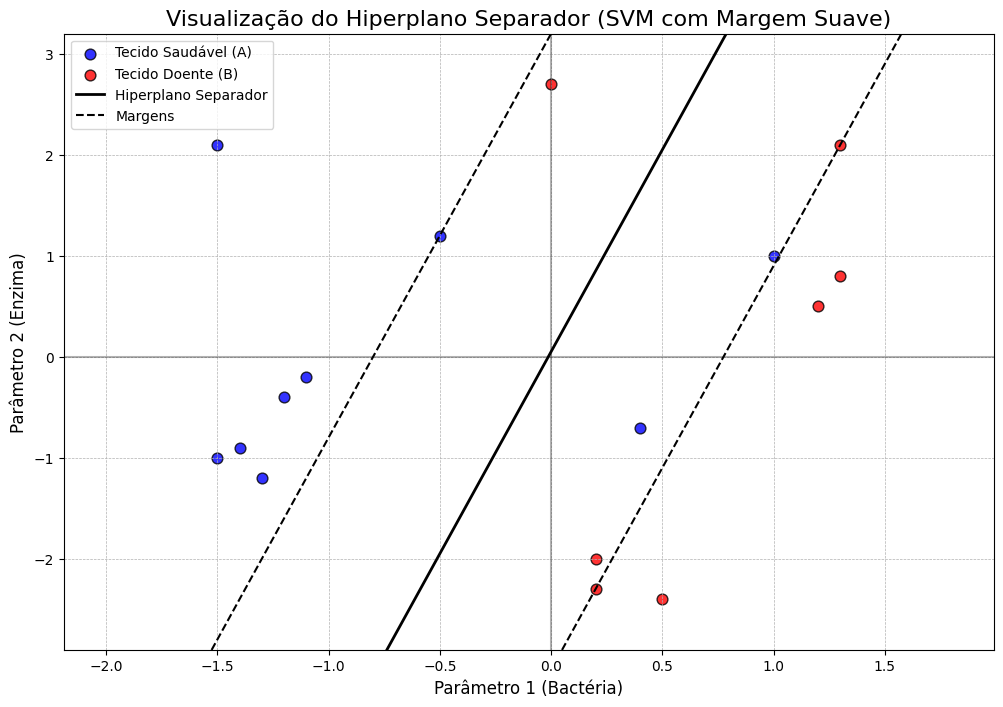

In [ ]:
import matplotlib.pyplot as plt

# Configura a figura
fig, ax = plt.subplots(figsize=(12, 8))

# Plota os pontos da Matriz A (saudável) em azul
ax.scatter(A[:, 0], A[:, 1], c='blue', label='Tecido Saudável (A)', s=60, edgecolor='k', alpha=0.8)

# Plota os pontos da Matriz B (doente) em vermelho
ax.scatter(B[:, 0], B[:, 1], c='red', label='Tecido Doente (B)', s=60, edgecolor='k', alpha=0.8)

# Para plotar as linhas, precisamos de um intervalo de valores para o eixo x
# Pegamos o mínimo e o máximo dos dados e adicionamos uma margem
x_min = min(A[:, 0].min(), B[:, 0].min()) - 0.5
x_max = max(A[:, 0].max(), B[:, 0].max()) + 0.5
x_vals = np.linspace(x_min, x_max, 100)

# A equação do hiperplano é a_0*x + a_1*y - b = k
# Rearranjando para y: y = (-a_0*x + b + k) / a_1
a0, a1 = a_sol

# Hiperplano central (k=0)
y_central = (-a0 * x_vals + b_sol) / a1
ax.plot(x_vals, y_central, 'k-', linewidth=2, label='Hiperplano Separador')

# Hiperplano da margem de B (k=1)
y_margem_B = (-a0 * x_vals + b_sol + 1) / a1
ax.plot(x_vals, y_margem_B, 'k--', linewidth=1.5, label='Margens')

# Hiperplano da margem de A (k=-1)
y_margem_A = (-a0 * x_vals + b_sol - 1) / a1
ax.plot(x_vals, y_margem_A, 'k--', linewidth=1.5)

# --- 5. Melhorias e Exibição do Gráfico ---

# Adiciona títulos, legendas e grade
ax.set_title('Visualização do Hiperplano Separador (SVM com Margem Suave)', fontsize=16)
ax.set_xlabel('Parâmetro 1 (Bactéria)', fontsize=12)
ax.set_ylabel('Parâmetro 2 (Enzima)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.axhline(y=0, color='k', alpha=0.3)
ax.axvline(x=0, color='k', alpha=0.3)

# Define limites para o gráfico ficar bem enquadrado
y_min = min(A[:, 1].min(), B[:, 1].min()) - 0.5
y_max = max(A[:, 1].max(), B[:, 1].max()) + 0.5
ax.set_ylim([y_min, y_max])

# Mostra o gráfico
plt.show()